# Modelling of Gaseous Nebulae

In [43]:
import matplotlib.pyplot as plt
import pandas as pd
plt.style.use('seaborn-v0_8-deep')
plt.rcParams.update({'font.size': 12})
plt.rcParams['figure.dpi'] = 100

### Overview

This notebook shows the result of a simulation done with Cloudy (Ferland et al. 1998), a photoionization and spectral synthesis code, to model the emission spectra of two astrophysical environments driven by AGN or stellar radiation:

1. Planetary Nebula (PN): a shell of gas ejected by a dying low-mass star, ionized by its hot remnant white dwarf core.
2. Broad Line Region (BLR): dense, high-velocity clouds surrounding the supermassive black hole in an AGN, responsible for the broad emission lines ($\text{H}\alpha$, $\text{H}\beta$, etc.) seen in quasar spectra.

Cloudy solves the coupled equations of ionization equilibrium, thermal equilibrium, and radiative transfer across a *zone* of gas, given an incident radiation field, hydrogen density, and chemical composition. The output continuum (`.con`) and line (`.line`) files encode the emergent spectrum and line intensities.


# Simulation of a Planetary Nebula (PN)

## Model setup

Two cloudy runs are compared: first for the PN abundances and then for solar abundances. For the former the following input code is used:

```
blackbody, T=1e5 K
luminosity total 38
radius 18
hden 5
sphere 
abundances planetary nebula
iterate
print last iteration
save overview "pn.ovr" last
save continuum "pn.con" units microns last
```

For the solar abundances the line ```abundances planetary nebula``` is removed, as by default Cloudy uses solar abundances.

The resulting continuum for the PN is shown below:

In [44]:
out = pd.read_table('pn.con')
out.head()

,#Cont nu,incident,trans,DiffOut,net trans,reflc,total,reflin,outlin,lineID,cont,nLine
0,29929300.0,1.711000e+12,0.0,3.085000e+26,3.085000e+26,0.0,3.085000e+26,0.0,0.0,,,0.0
1,29829700.0,1.728000e+12,0.0,3.119000e+26,3.119000e+26,0.0,3.119000e+26,0.0,0.0,,,0.0
2,29730400.0,1.745000e+12,0.0,3.154000e+26,3.154000e+26,0.0,3.154000e+26,0.0,0.0,,,0.0
3,29631500.0,1.763000e+12,0.0,3.189000e+26,3.189000e+26,0.0,3.189000e+26,0.0,0.0,,,0.0
4,29532900.0,1.781000e+12,0.0,3.224000e+26,3.224000e+26,0.0,3.224000e+26,0.0,0.0,,,0.0


In [45]:
# Change name
out.rename(columns={'#Cont  nu':'wavelength'}, inplace=True)

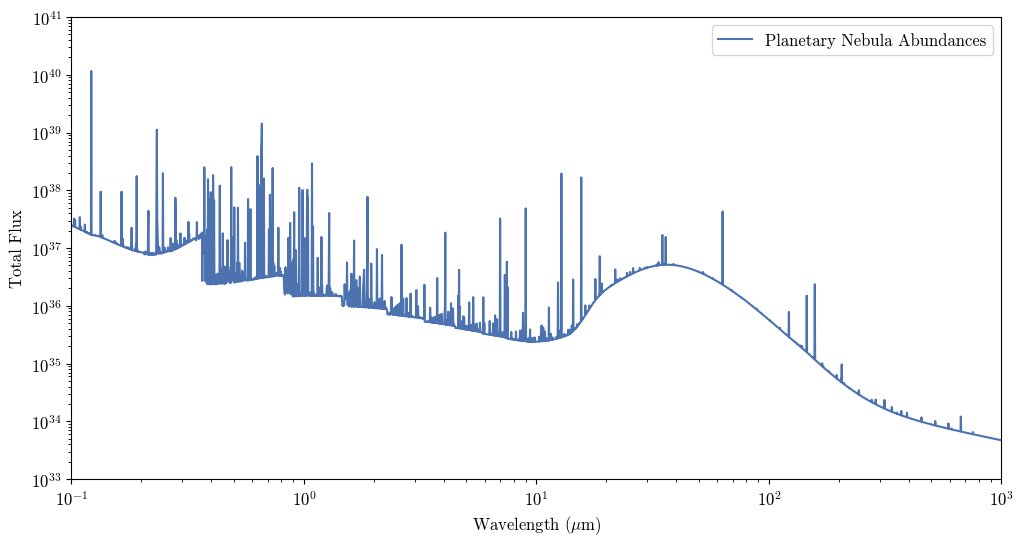

In [46]:
plt.figure(figsize=(12,6))
plt.plot(out['wavelength'],out['total'], label='Planetary Nebula Abundances')
plt.xlabel(r'Wavelength ($\mu$m)')
plt.ylabel('Total Flux')
plt.xscale('log')
plt.yscale('log')
plt.xlim(1e-1,1e3)
plt.ylim(1e33,1e41)
plt.legend()
plt.show()

And the results with the solar abundances:


In [47]:
out2 = pd.read_table('solar.con')
out2.head()

,#Cont nu,incident,trans,DiffOut,net trans,reflc,total,reflin,outlin,lineID,cont,nLine
0,29929300.0,1.711000e+12,0.0,2.140000e+26,2.140000e+26,0.0,2.140000e+26,0.0,0.0,,,0.0
1,29829700.0,1.728000e+12,0.0,2.163000e+26,2.163000e+26,0.0,2.163000e+26,0.0,0.0,,,0.0
2,29730400.0,1.745000e+12,0.0,2.187000e+26,2.187000e+26,0.0,2.187000e+26,0.0,0.0,,,0.0
3,29631500.0,1.763000e+12,0.0,2.210000e+26,2.210000e+26,0.0,2.210000e+26,0.0,0.0,,,0.0
4,29532900.0,1.781000e+12,0.0,2.234000e+26,2.234000e+26,0.0,2.234000e+26,0.0,0.0,,,0.0


In [48]:
out2.rename(columns={'#Cont  nu':'wavelength'}, inplace=True)

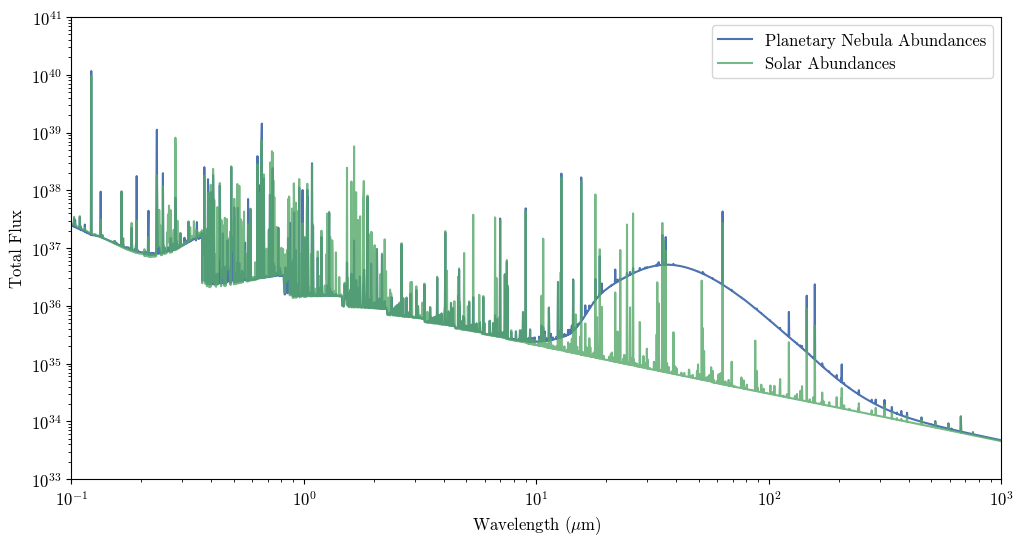

In [49]:
plt.figure(figsize=(12,6))
plt.plot(out['wavelength'],out['total'], label='Planetary Nebula Abundances')
plt.plot(out2['wavelength'],out2['total'], label='Solar Abundances',alpha=0.8)
plt.xlabel(r'Wavelength ($\mu$m)')
plt.ylabel('Total Flux')
plt.xscale('log')
plt.yscale('log')
plt.xlim(1e-1,1e3)
plt.ylim(1e33,1e41)
plt.legend()
plt.show()

## PN vs Solar abundances

The most visually obvious feature is the broad thermal emission hump in the PN case around 20-30 $\mu\text{m}$ which is absent in the solar case and is the result of dust emission.


## Temperature of the PN

In [50]:
ovr_pn = pd.read_table('pn.ovr')
ovr_pn.head()

,#depth,Te,Htot,hden,eden,2H_2/H,HI,HII,HeI,HeII,...,O1,O2,O3,O4,O5,O6,H2O/O,AV(point),AV(extend),Tau912
0,8.684890e+09,10530.0,4.090000e-14,100000.0,96426.0,2.779900e-10,0.13715,0.86285,0.10177,0.85927,...,0.16022,0.82004,0.019736,0.000010,1.175500e-36,1.175500e-36,1.218800e-19,9.370000e-07,6.990000e-07,0.001508
1,5.210940e+10,10526.0,4.067000e-14,100000.0,96015.0,2.766900e-10,0.13639,0.86361,0.10140,0.85947,...,0.15933,0.82079,0.019874,0.000011,1.175500e-36,1.175500e-36,1.187500e-19,4.690000e-06,3.490000e-06,0.007505
2,2.258070e+11,10514.0,4.040000e-14,100000.0,95972.0,2.764700e-10,0.13581,0.86419,0.10154,0.85936,...,0.15867,0.82135,0.019973,0.000011,1.175500e-36,1.175500e-36,1.169500e-19,1.970000e-05,1.470000e-05,0.031392
3,9.205990e+11,10491.0,3.975000e-14,100000.0,96026.0,2.774000e-10,0.13511,0.86489,0.10232,0.85885,...,0.15787,0.82203,0.020084,0.000011,1.175500e-36,1.175500e-36,1.150000e-19,7.970000e-05,5.940000e-05,0.126440
4,2.199010e+12,10413.0,3.778000e-14,100000.0,96562.0,2.688000e-10,0.12840,0.87160,0.10328,0.85820,...,0.15010,0.82838,0.021508,0.000012,1.175500e-36,1.175500e-36,9.724400e-20,1.580000e-04,1.170000e-04,0.243890


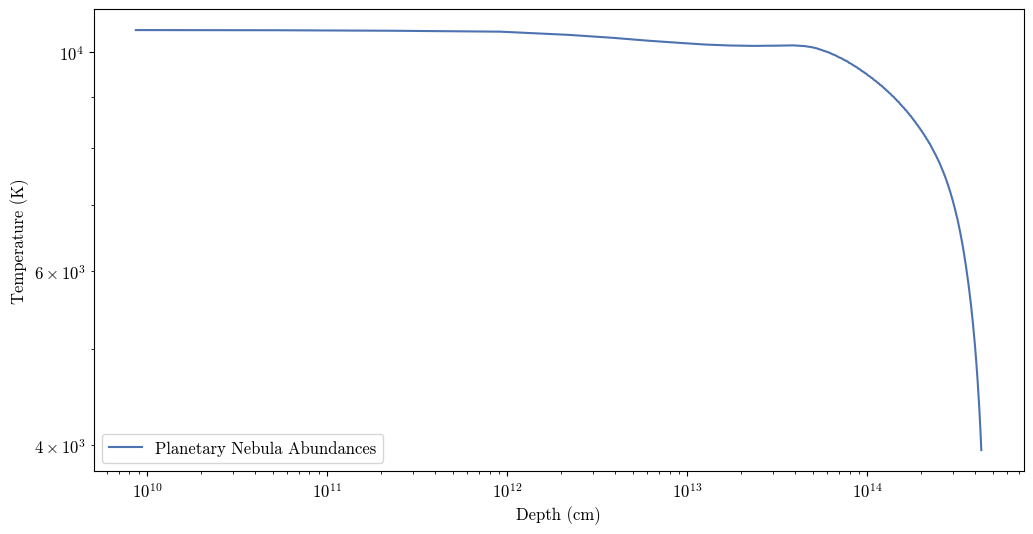

In [51]:
plt.figure(figsize=(12,6))
plt.plot(ovr_pn['#depth'],ovr_pn['Te'], label='Planetary Nebula Abundances')
plt.xlabel('Depth (cm)')
plt.ylabel('Temperature (K)')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

The plot shows electron temperature vs. depth into the nebular shell (from the inner edge near the ionizing source outward). We can see that in the zone closest to the source is fully ionized and the temperature remains rougly constant at around $10^{4} \text{K}$. Then there is a sharp decrease which indicates the  photoionization heating drops.

# Simulation of the Broad Line Region (BLR)

## Single-cloud model
We first run a single BLR cloud (log $n_H$ = 10, log $\Phi$ = 18.5) to inspect the emergent spectrum before running a full parameter grid.

In [52]:
blr_con = pd.read_table('blr_single.con')
blr_con.head()

,#Cont nu,incident,trans,DiffOut,net trans,reflc,total,reflin,outlin,lineID,cont,nLine
0,29929300.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,,,0.0
1,29829700.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,,,0.0
2,29730400.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,,,0.0
3,29631500.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,,,0.0
4,29532900.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,,,0.0


In [53]:
blr_con.rename(columns={'#Cont  nu':'wavelength'}, inplace=True)

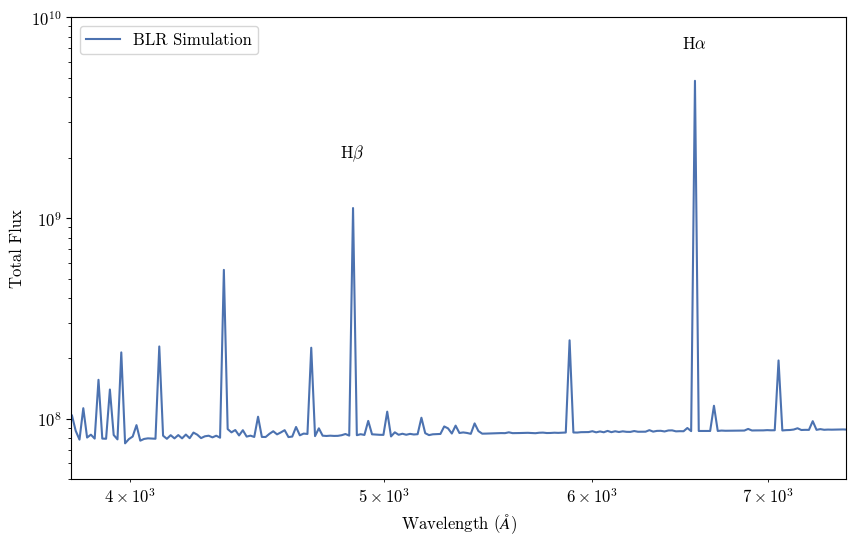

In [54]:
blr_con['wavelength_angstroms'] = blr_con['wavelength'] * 1e4

plt.figure(figsize=(10,6))
plt.plot(blr_con['wavelength_angstroms'],blr_con['total'], label='BLR Simulation')
plt.xlabel(r'Wavelength ($\AA$)')
plt.ylabel('Total Flux')
plt.xscale('log')
plt.yscale('log')
plt.xlim(3800,7500)
plt.ylim(5e7,1e10)
plt.text(6562.8,7e9,r'H$\alpha$', fontsize=12, ha='center')
plt.text(4861.3,2e9,r'H$\beta$', fontsize=12, ha='center')
plt.legend()
plt.show()

The spectrum is shown in the optical window (3800–7500 $\AA$) where the BLR emission lines are observed. 

The labelled lines are:
- **$\text{H}\alpha$ (6563 $\AA$)**
- **$\text{H}\beta$ (4861 $\AA$)**

Their relative strenghts, namely the Balmer ratio have been used as indicators of dust extinction by comparing them with predictions from theoretical models. It is used because of its relative insensitivity to gas conditions such as temperature and density, and the both lines are relatively strong and commonly accessible (Son et al 2025, arxiv:2511.07714).

Many line transfer effects are very important in the BLR. It is necessary to iterate on the solution to converge the optical depths. The obtained ratio of $\text{H}\alpha / \text{H}\beta$ after 4 iterations is 4.57

In [55]:
blr_singgle_line = pd.read_table('blr_single.line')
blr_singgle_line

,#lineslist,H 1 6562.80A /H 1 4861.32A
0,iteration 1,4.7613
1,iteration 2,4.4463
2,iteration 3,4.6322
3,iteration 4,4.5693


## Parameter Grid

To map how $\text{H}\alpha / \text{H}\beta$ depends on cloud conditions, we run a 2D grid spanning the BLR parameter space. The grid (`blr.grd`, `blr.line`) contains 169 models covering all combinations of:

| Parameter | Range | Steps |
|-----------|-------|-------|
| log $\Phi$(H) — ionizing photon flux | 18–24 | 0.5 (13 values) |
| log $n_H$ — hydrogen density ($\text{cm}^{-3}$) | 8–14 | 0.5 (13 values) |

Each grid point is an independent Cloudy run; the grid was computed in parallel over 8 CPU threads.

In [56]:
line_ratios = pd.read_table('blr.line')
line_ratios.columns

Index(['#lineslist', 'H  1 6562.80A /H  1 4861.32A '], dtype='str')

In [57]:
ha_hb = line_ratios['H  1 6562.80A /H  1 4861.32A ']
print(ha_hb)

0      2.73240
1      2.92270
2      8.02730
3      8.40850
4      6.79910
        ...   
164    2.94660
165    2.78660
166    2.55760
167    1.62770
168    0.65172
Name: H  1 6562.80A /H  1 4861.32A , Length: 169, dtype: float64


In [58]:
grid = pd.read_table('blr.grd',index_col=0)
grid.head()

,Failure?,Warnings?,Exit code,#rank,#seq,phi(h) %f,HDEN=%f L,grid parameter string
#Index,,,,,,,,
0,F,F,ok,6,5,18.0,8.0,"18.000000, 8.000000"
1,F,F,ok,7,1,18.0,8.5,"18.000000, 8.500000"
2,F,F,ok,1,6,18.0,9.0,"18.000000, 9.000000"
3,F,F,ok,3,9,18.0,9.5,"18.000000, 9.500000"
4,F,F,ok,6,15,18.0,10.0,"18.000000, 10.000000"


In [59]:
grid.columns

Index(['Failure?', 'Warnings?', 'Exit code', '#rank', '#seq', 'phi(h) %f',
       'HDEN=%f L', 'grid parameter string'],
      dtype='str')

In [60]:
flux = grid[r'phi(h) %f']
density = grid[r'HDEN=%f L']

Below is shown how the $\text{H}\alpha / \text{H}\beta$ ratio varies across the parameter plane

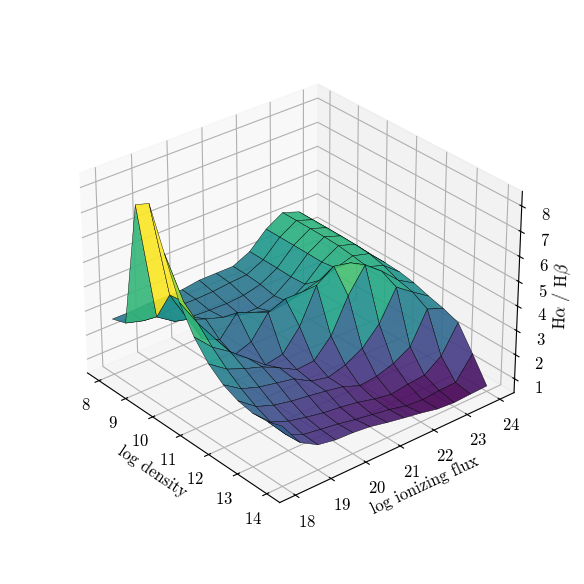

In [61]:
import numpy as np

flux_grid = np.unique(flux)
density_grid = np.unique(density)

Z = ha_hb.values.reshape(len(flux_grid), len(density_grid))
X, Y = np.meshgrid(density_grid, flux_grid)

fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot(111, projection='3d')
#ax.set_title(" " * 35 + "Your Title" + " " * 35)
ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='k', linewidth=0.3, alpha=0.9)
ax.set_ylabel('log ionizing flux')
ax.set_xlabel('log density')
ax.set_zlabel(r'H$\alpha$ / H$\beta$', labelpad=-0.1)
ax.view_init(elev=30, azim=-40)
plt.tight_layout()
ax.set_box_aspect(None, zoom=0.85)
plt.show()

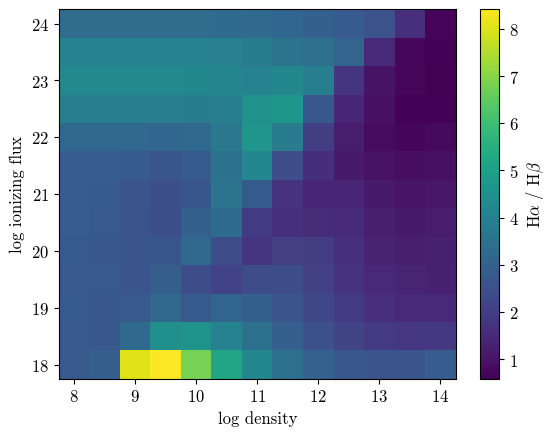

In [62]:
plt.pcolormesh(X, Y, Z, cmap='viridis')
#plt.imshow(Z,cmap='viridis',extent=(density.min(), density.max(), flux_grid.min(), flux_grid.max()), aspect='auto')
plt.colorbar(label=r'H$\alpha$ / H$\beta$')
plt.ylabel('log ionizing flux')
plt.xlabel('log density')
plt.show()

The range of observed Balmer decrements in the literature for different type 1 AGN samples is $\text{H}\alpha / \text{H}\beta \approx 2.7-3.5$ (Son et al 2025, arxiv:2511.07714); which in the obtained plot corresponds roughly to $\log\Phi \approx 20-23$ and $\log n \approx 9-12$ 

## Computational Cost

The CPU time for the simulation of the PN and the BLR are shown below

In [ ]:
import re

def get_exec_time(filename):    
    with open(filename) as f:
        for line in f:
            if "ExecTime" in line:
                match = re.search(r"ExecTime\(s\)\s+([\d.]+)", line)
                if match:
                    print(f"{filename}: {match.group(1)} seconds")

get_exec_time("pn.out")
get_exec_time("solar.out")
get_exec_time("blr_single.out")


pn.out: 35.85 seconds
solar.out: 36.91 seconds
blr_single.out: 184.51 seconds


To look at the CPU time for the grid we need to check each point:

In [77]:
import re

total = 0.0
count = -1 # The first line is just the creation of the input files so we don't count it

with open("blr.out") as f:
    for line in f:
        if "ExecTime" in line:
            match = re.search(r"ExecTime\(s\)\s+([\d.]+)", line)
            if match:
                total += float(match.group(1))
                count += 1

print(f"Grid points: {count}")
print(f"Total CPU time: {total:.1f} s ({total/60:.1f} min) ({total/3600:.1f} hr)")
print(f"Wall clock time (8 threads): {total/3600/8:.1f} hr")
print(f"Average per model: {total/count:.2f} s")

Grid points: 169
Total CPU time: 50868.0 s (847.8 min) (14.1 hr)
Wall clock time (8 threads): 1.8 hr
Average per model: 300.99 s
